# 04 – Pipeline Testing & End-to-End Validation
**Proyek Capstone – Sistem Deteksi Anomali Kualitas Udara**  
**Kelompok Aeris | PENS 2026**  
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 4 | 18 Mei – 24 Mei 2026**  
Fase: Phase 3 – Deployment & Integrasi

**Checklist Minggu 4 (Linda):**
- [x] Uji pipeline end-to-end: fetch → preprocess → predict → save
- [x] Verifikasi segmentasi waktu berjalan benar di real-time
- [x] Monitor hasil prediksi: apakah masuk akal vs data aktual?
- [x] Analisis anomali: jam berapa dan segmen apa paling sering anomali
- [x] Buat `src/models/train_model.py` sebagai script standalone
- [x] Buat `src/models/predict_model.py` untuk inferensi
- [x] Dokumentasikan pipeline di `reports/pipeline_doc.md`

**Input:** `data/processed/surabaya_processed.csv` + 15 model `.pkl`  
**Output:** Validasi pipeline + `src/models/train_model.py` + `src/models/predict_model.py` + `reports/pipeline_doc.md`

## 1. Setup

In [1]:
import os
import sys

# Pindah ke root project
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

for folder in ["src/models", "src/data", "src/api", "reports"]:
    os.makedirs(folder, exist_ok=True)

# Tambah root ke sys.path supaya bisa import src/
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

Working directory: d:\mlops\aeris-air-quality


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import warnings
from datetime import datetime, timedelta
import requests
warnings.filterwarnings("ignore")

from pycaret.regression import load_model, predict_model

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
SEGMEN  = ["PAGI", "SIANG", "SORE_MALAM"]

print("Library loaded")

Library loaded


## 2. Verifikasi Segmentasi Waktu Real-time
Pastikan sistem bisa deteksi segmen waktu yang tepat berdasarkan jam sekarang

In [3]:
def get_time_segment(hour=None):
    """Deteksi segmen waktu berdasarkan jam."""
    if hour is None:
        hour = datetime.now().hour
    if 6 <= hour <= 11:
        return "PAGI"
    elif 12 <= hour <= 17:
        return "SIANG"
    else:
        return "SORE_MALAM"

def get_model_path(polutan, segmen):
    """Dapatkan path model berdasarkan polutan dan segmen."""
    return f"models/{polutan}_{segmen.lower()}_best"

# Test segmentasi
print("Verifikasi segmentasi waktu:")
print(f"{'Jam':>6} | {'Segmen':<15} | {'Model PM25 yang diload'}")
print("-" * 55)
for jam in [0, 3, 6, 8, 11, 12, 15, 17, 18, 20, 23]:
    seg = get_time_segment(jam)
    path = get_model_path("pm25", seg)
    print(f"  {jam:02d}:00 | {seg:<15} | {path}.pkl")

print()
# Segmen saat ini
now = datetime.now()
seg_now = get_time_segment()
print(f"Jam sekarang : {now.strftime('%H:%M')}")
print(f"Segmen aktif : {seg_now}")
print(f"Model yang diload: models/[polutan]_{seg_now.lower()}_best.pkl")

Verifikasi segmentasi waktu:
   Jam | Segmen          | Model PM25 yang diload
-------------------------------------------------------
  00:00 | SORE_MALAM      | models/pm25_sore_malam_best.pkl
  03:00 | SORE_MALAM      | models/pm25_sore_malam_best.pkl
  06:00 | PAGI            | models/pm25_pagi_best.pkl
  08:00 | PAGI            | models/pm25_pagi_best.pkl
  11:00 | PAGI            | models/pm25_pagi_best.pkl
  12:00 | SIANG           | models/pm25_siang_best.pkl
  15:00 | SIANG           | models/pm25_siang_best.pkl
  17:00 | SIANG           | models/pm25_siang_best.pkl
  18:00 | SORE_MALAM      | models/pm25_sore_malam_best.pkl
  20:00 | SORE_MALAM      | models/pm25_sore_malam_best.pkl
  23:00 | SORE_MALAM      | models/pm25_sore_malam_best.pkl

Jam sekarang : 18:19
Segmen aktif : SORE_MALAM
Model yang diload: models/[polutan]_sore_malam_best.pkl


## 3. Load Data & Verifikasi Model
Cek semua 15 model bisa di-load dengan benar

In [4]:
# Load data processed
df = pd.read_csv("data/processed/surabaya_processed.csv",
                 parse_dates=["time"])
print(f"Data loaded: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Rentang: {df['time'].min().date()} -> {df['time'].max().date()}")

# Verifikasi semua model bisa di-load
print("\nVerifikasi load 15 model:")
models = {}
all_loaded = True

for seg in SEGMEN:
    for pol in POLUTAN:
        key  = f"{pol}_{seg.lower()}"
        path = f"models/{key}_best"
        try:
            models[key] = load_model(path, verbose=False)
            print(f"  [OK] {path}.pkl")
        except Exception as e:
            print(f"  [GAGAL] {path}.pkl -> {e}")
            all_loaded = False

print()
if all_loaded:
    print("Semua 15 model berhasil di-load!")
else:
    print("Ada model yang gagal di-load, cek path!")

Data loaded: 3,360 baris x 69 kolom
Rentang: 2026-01-02 -> 2026-05-21

Verifikasi load 15 model:
  [OK] models/pm25_pagi_best.pkl
  [OK] models/pm10_pagi_best.pkl
  [OK] models/co_pagi_best.pkl
  [OK] models/no2_pagi_best.pkl
  [OK] models/o3_pagi_best.pkl
  [OK] models/pm25_siang_best.pkl
  [OK] models/pm10_siang_best.pkl
  [OK] models/co_siang_best.pkl
  [OK] models/no2_siang_best.pkl
  [OK] models/o3_siang_best.pkl
  [OK] models/pm25_sore_malam_best.pkl
  [OK] models/pm10_sore_malam_best.pkl
  [OK] models/co_sore_malam_best.pkl
  [OK] models/no2_sore_malam_best.pkl
  [OK] models/o3_sore_malam_best.pkl

Semua 15 model berhasil di-load!


## 4. Uji Pipeline End-to-End
Simulasi alur lengkap: ambil data terbaru → preprocess → prediksi → simpan

In [5]:
# ── STEP 1: Fetch data terbaru (simulasi real-time) ──────────────
print("STEP 1: Fetch data terbaru dari Open-Meteo")
print("-" * 50)

LAT, LON   = -7.2575, 112.7521
END_DATE   = datetime.today().strftime("%Y-%m-%d")
START_DATE = (datetime.today() - timedelta(days=2)).strftime("%Y-%m-%d")

resp_aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude" : LAT, "longitude": LON,
        "hourly"   : ["pm2_5","pm10","carbon_monoxide",
                      "nitrogen_dioxide","ozone"],
        "timezone" : "Asia/Jakarta",
        "start_date": START_DATE, "end_date": END_DATE
    }
)
resp_w = requests.get(
    "https://api.open-meteo.com/v1/forecast",
    params={
        "latitude" : LAT, "longitude": LON,
        "hourly"   : ["temperature_2m","relative_humidity_2m",
                      "wind_speed_10m","wind_direction_10m","precipitation"],
        "timezone" : "Asia/Jakarta",
        "start_date": START_DATE, "end_date": END_DATE
    }
)

df_aq = pd.DataFrame(resp_aq.json()["hourly"])
df_w  = pd.DataFrame(resp_w.json()["hourly"])
df_aq["time"] = pd.to_datetime(df_aq["time"])
df_w["time"]  = pd.to_datetime(df_w["time"])
df_w.rename(columns={"relative_humidity_2m": "relative_humidity"}, inplace=True)

df_latest = pd.merge(df_aq, df_w, on="time", how="inner")
df_latest.rename(columns={
    "pm2_5": "pm25", "carbon_monoxide": "co",
    "nitrogen_dioxide": "no2", "ozone": "o3"
}, inplace=True)

print(f"Data terbaru: {len(df_latest)} baris")
print(f"Dari {df_latest['time'].min()} -> {df_latest['time'].max()}")
print("STEP 1 selesai")

STEP 1: Fetch data terbaru dari Open-Meteo
--------------------------------------------------
Data terbaru: 72 baris
Dari 2026-05-20 00:00:00 -> 2026-05-22 23:00:00
STEP 1 selesai


In [6]:
# ── STEP 2: Preprocess data terbaru ──────────────────────────────
print("STEP 2: Preprocess data terbaru")
print("-" * 50)

# Gabung dengan data historis untuk hitung lag/rolling
df_hist = pd.read_csv("data/processed/surabaya_processed.csv",
                      parse_dates=["time"])

# Fungsi preprocess
def preprocess_realtime(df_new, df_hist):
    """Preprocess data real-time dengan fitur lag & rolling."""
    # Ambil data historis 24 jam terakhir + data baru
    df_combined = pd.concat([df_hist, df_new], ignore_index=True)
    df_combined = df_combined.drop_duplicates(subset=["time"]).sort_values("time").reset_index(drop=True)

    # Fitur waktu
    df_combined["hour"]        = df_combined["time"].dt.hour
    df_combined["day_of_week"] = df_combined["time"].dt.dayofweek
    df_combined["month"]       = df_combined["time"].dt.month
    df_combined["is_weekend"]  = (df_combined["day_of_week"] >= 5).astype(int)

    def assign_segment(h):
        if 6 <= h <= 11:   return "PAGI"
        elif 12 <= h <= 17: return "SIANG"
        else:               return "SORE_MALAM"
    df_combined["time_segment"] = df_combined["hour"].apply(assign_segment)

    # Fitur lag & rolling per polutan
    polutan_cols = ["pm25", "pm10", "co", "no2", "o3"]
    for pol in polutan_cols:
        if pol not in df_combined.columns:
            continue
        for lag in [1, 3, 24]:
            df_combined[f"{pol}_lag_{lag}h"] = df_combined[pol].shift(lag)
        for roll, func in [(3, "mean"), (24, "mean"), (24, "std"), (24, "max")]:
            suffix = f"rolling_{func}_{roll}h"
            rolled = df_combined[pol].rolling(window=roll, min_periods=1)
            df_combined[f"{pol}_{suffix}"] = getattr(rolled, func)()
        df_combined[f"{pol}_diff_1h"]       = df_combined[pol].diff(1)
        df_combined[f"{pol}_pct_change_1h"] = df_combined[pol].pct_change(1).replace([np.inf, -np.inf], 0)

    # Ambil hanya data baru (bukan historis)
    df_result = df_combined[df_combined["time"].isin(df_new["time"])].copy()
    return df_result.dropna(subset=[f"{p}_lag_24h" for p in polutan_cols if f"{p}_lag_24h" in df_result.columns])

df_processed = preprocess_realtime(df_latest, df_hist)
print(f"Data setelah preprocess: {len(df_processed)} baris")
print(f"Kolom: {df_processed.shape[1]}")
print("STEP 2 selesai")

STEP 2: Preprocess data terbaru
--------------------------------------------------
Data setelah preprocess: 72 baris
Kolom: 69
STEP 2 selesai


In [7]:
# ── STEP 3: Prediksi menggunakan model sesuai segmen ─────────────
print("STEP 3: Prediksi polutan per segmen")
print("-" * 50)

BASE_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend",
    "temperature_2m", "relative_humidity",
    "wind_speed_10m", "wind_direction_10m", "precipitation",
]
for p in POLUTAN:
    for lag in [1, 3, 24]:
        BASE_FEATURES.append(f"{p}_lag_{lag}h")
    for roll in ["rolling_mean_3h", "rolling_mean_24h",
                 "rolling_std_24h", "rolling_max_24h"]:
        BASE_FEATURES.append(f"{p}_{roll}")
    BASE_FEATURES.append(f"{p}_diff_1h")
    BASE_FEATURES.append(f"{p}_pct_change_1h")

hasil_prediksi = []

for _, row in df_processed.iterrows():
    segmen  = row["time_segment"]
    pred_row = {"time": row["time"], "segmen": segmen}

    for pol in POLUTAN:
        key        = f"{pol}_{segmen.lower()}"
        feat_avail = [
            c for c in BASE_FEATURES
            if c in df_processed.columns
            and c != pol
            and not c.startswith(f"{pol}_")
        ]

        try:
            df_input = pd.DataFrame([row[feat_avail]])
            # Log-transform CO sebelum prediksi
            if pol == "co" and "co" in df_input.columns:
                df_input["co"] = np.log1p(df_input["co"])

            hasil = predict_model(models[key], data=df_input, verbose=False)
            pred_val = hasil["prediction_label"].values[0]

            # Inverse log-transform untuk CO
            if pol == "co":
                pred_val = np.expm1(pred_val)

            pred_row[f"{pol}_pred"] = round(float(pred_val), 4)
            pred_row[f"{pol}_actual"] = round(float(row[pol]), 4) if not pd.isna(row[pol]) else None
        except Exception as e:
            pred_row[f"{pol}_pred"]   = None
            pred_row[f"{pol}_actual"] = None

    hasil_prediksi.append(pred_row)

df_pred = pd.DataFrame(hasil_prediksi)
print(f"Hasil prediksi: {len(df_pred)} baris")
print("STEP 3 selesai")
df_pred.tail(5)

STEP 3: Prediksi polutan per segmen
--------------------------------------------------
Hasil prediksi: 72 baris
STEP 3 selesai


,time,segmen,pm25_pred,pm25_actual,pm10_pred,pm10_actual,co_pred,co_actual,no2_pred,no2_actual,o3_pred,o3_actual
67,2026-05-22 19:00:00,SORE_MALAM,57.0151,57.7,58.6259,58.0,2177.1726,6285.0,71.0594,74.6,31.2773,30.0
68,2026-05-22 20:00:00,SORE_MALAM,56.5411,57.5,58.4511,57.6,1598.0544,6101.0,76.1282,78.3,23.7473,18.0
69,2026-05-22 21:00:00,SORE_MALAM,60.3115,61.0,61.7889,61.2,2122.9111,5302.0,70.9191,76.7,18.7281,13.0
70,2026-05-22 22:00:00,SORE_MALAM,61.8202,62.2,62.6826,62.4,1467.5375,4351.0,70.0254,72.6,14.8087,11.0
71,2026-05-22 23:00:00,SORE_MALAM,58.6136,59.1,59.6977,59.3,1562.0583,3233.0,67.1448,65.2,18.4246,12.0


In [8]:
# ── STEP 4: Simpan hasil prediksi ────────────────────────────────
print("STEP 4: Simpan hasil prediksi")
print("-" * 50)

pred_path = "data/processed/pipeline_test_predictions.csv"
df_pred.to_csv(pred_path, index=False)
print(f"Hasil prediksi disimpan -> {pred_path}")
print("STEP 4 selesai")
print()
print("Pipeline end-to-end BERHASIL!")
print("Alur: Fetch -> Preprocess -> Predict -> Save")

STEP 4: Simpan hasil prediksi
--------------------------------------------------
Hasil prediksi disimpan -> data/processed/pipeline_test_predictions.csv
STEP 4 selesai

Pipeline end-to-end BERHASIL!
Alur: Fetch -> Preprocess -> Predict -> Save


## 5. Monitor Hasil Prediksi vs Aktual

In [9]:
print("Monitor Prediksi vs Aktual")
print("=" * 55)

for pol in POLUTAN:
    pred_col   = f"{pol}_pred"
    actual_col = f"{pol}_actual"
    if pred_col not in df_pred.columns:
        continue

    valid = df_pred[[pred_col, actual_col]].dropna()
    if len(valid) == 0:
        continue

    mae  = np.mean(np.abs(valid[pred_col] - valid[actual_col]))
    rmse = np.sqrt(np.mean((valid[pred_col] - valid[actual_col])**2))

    print(f"\n{pol.upper()}:")
    print(f"  Actual  : mean={valid[actual_col].mean():.2f}  min={valid[actual_col].min():.2f}  max={valid[actual_col].max():.2f}")
    print(f"  Prediksi: mean={valid[pred_col].mean():.2f}  min={valid[pred_col].min():.2f}  max={valid[pred_col].max():.2f}")
    print(f"  MAE={mae:.4f}  RMSE={rmse:.4f}")

Monitor Prediksi vs Aktual

PM25:
  Actual  : mean=36.11  min=7.70  max=105.50
  Prediksi: mean=35.91  min=6.43  max=106.43
  MAE=0.7923  RMSE=0.9281

PM10:
  Actual  : mean=37.06  min=8.10  max=106.90
  Prediksi: mean=37.21  min=8.34  max=105.68
  MAE=0.8284  RMSE=0.9676

CO:
  Actual  : mean=1305.75  min=86.00  max=6285.00
  Prediksi: mean=1008.29  min=116.05  max=3453.33
  MAE=536.0129  RMSE=1112.5956

NO2:
  Actual  : mean=37.69  min=7.60  max=78.30
  Prediksi: mean=40.00  min=7.30  max=78.61
  MAE=3.8403  RMSE=6.9127

O3:
  Actual  : mean=41.71  min=0.00  max=134.00
  Prediksi: mean=50.30  min=-0.45  max=187.89
  MAE=8.7627  RMSE=15.7636


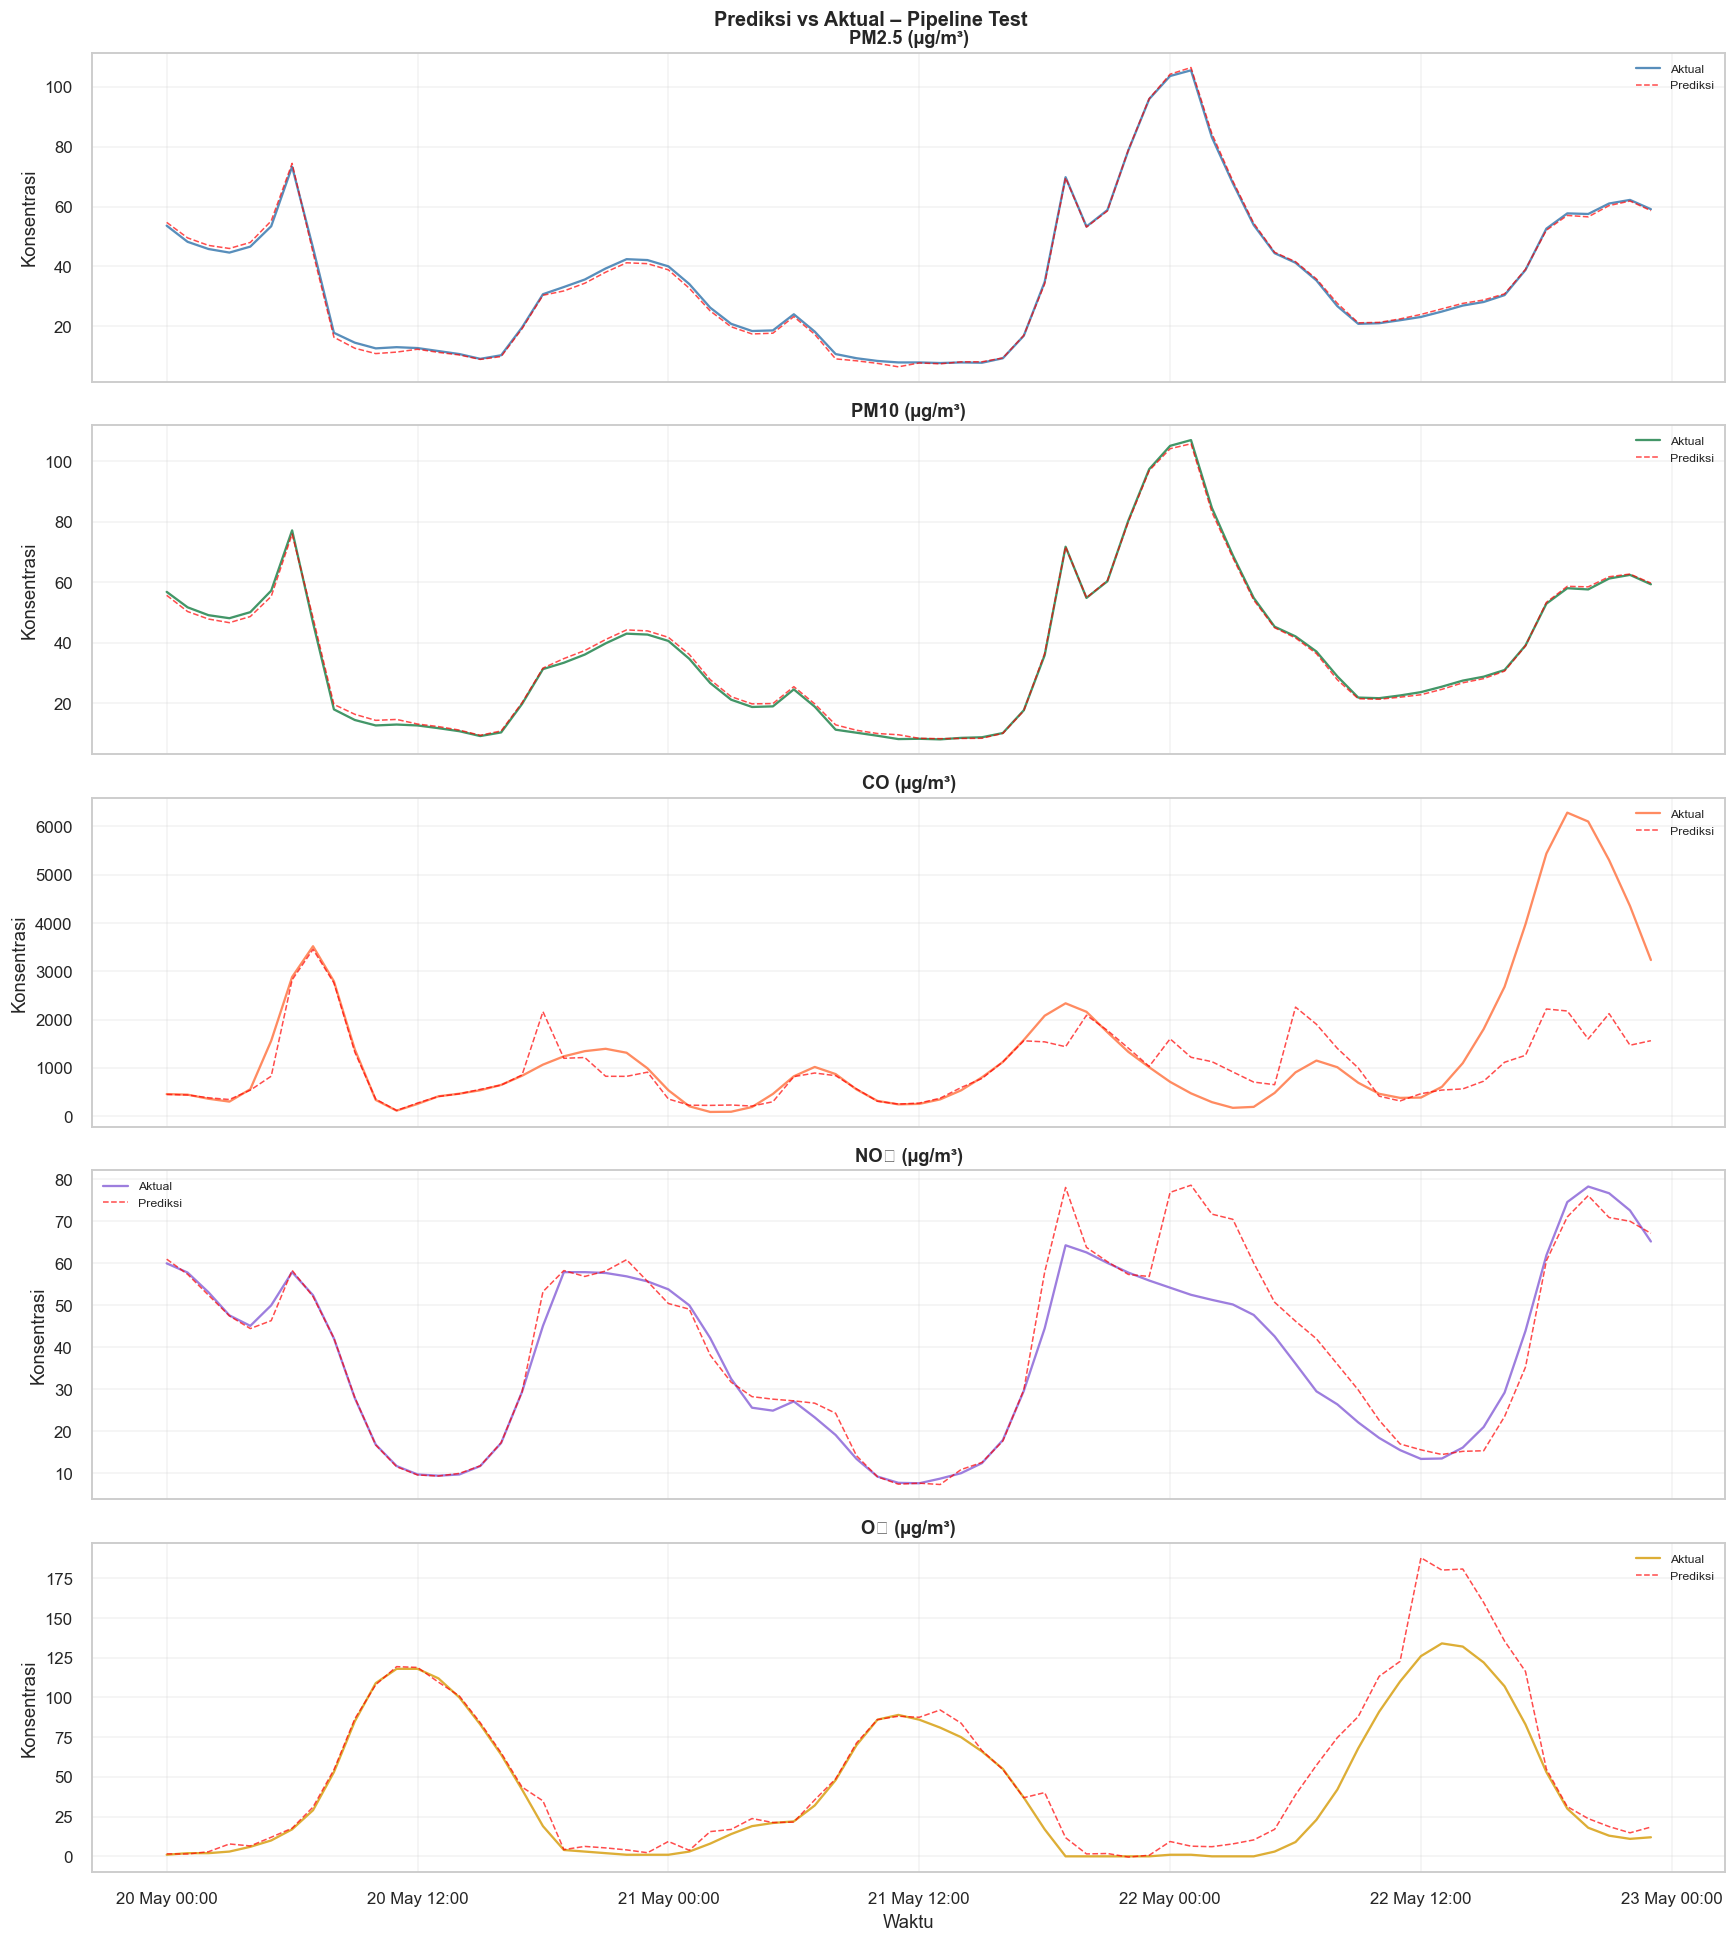

Disimpan -> reports/viz_pipeline_pred_vs_actual.png


In [10]:
# Visualisasi prediksi vs aktual
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

colors = ["steelblue", "seagreen", "coral", "mediumpurple", "goldenrod"]
labels = {"pm25": "PM2.5 (µg/m³)", "pm10": "PM10 (µg/m³)",
          "co": "CO (µg/m³)", "no2": "NO₂ (µg/m³)", "o3": "O₃ (µg/m³)"}

for ax, pol, color in zip(axes, POLUTAN, colors):
    pred_col   = f"{pol}_pred"
    actual_col = f"{pol}_actual"
    if pred_col not in df_pred.columns:
        continue
    valid = df_pred[["time", pred_col, actual_col]].dropna()
    ax.plot(valid["time"], valid[actual_col],
            color=color, lw=1.5, label="Aktual", alpha=0.9)
    ax.plot(valid["time"], valid[pred_col],
            color="red", lw=1, ls="--", label="Prediksi", alpha=0.7)
    ax.set_title(labels[pol], fontweight="bold")
    ax.set_ylabel("Konsentrasi")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
axes[-1].set_xlabel("Waktu")
plt.suptitle("Prediksi vs Aktual – Pipeline Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz_pipeline_pred_vs_actual.png",
            dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_pipeline_pred_vs_actual.png")

## 6. Analisis Anomali – Jam & Segmen Paling Sering Anomali

In [11]:
from sklearn.ensemble import IsolationForest

print("Analisis Anomali dengan Isolation Forest")
print("=" * 55)

# Gunakan data processed historis untuk deteksi anomali
df_anomaly = df.copy()
anomaly_features = POLUTAN  # deteksi anomali berdasarkan nilai polutan

X_anomaly = df_anomaly[anomaly_features].dropna()

# Train Isolation Forest
iso_forest = IsolationForest(
    contamination = 0.05,
    n_estimators  = 100,
    random_state  = 42
)
iso_forest.fit(X_anomaly)

# Prediksi anomali
df_anomaly = df_anomaly.loc[X_anomaly.index].copy()
df_anomaly["anomaly_score"] = iso_forest.decision_function(X_anomaly)
df_anomaly["is_anomaly"]    = iso_forest.predict(X_anomaly) == -1

total     = len(df_anomaly)
n_anomaly = df_anomaly["is_anomaly"].sum()
print(f"Total data    : {total:,} jam")
print(f"Anomali       : {n_anomaly:,} jam ({n_anomaly/total*100:.1f}%)")
print(f"Normal        : {total-n_anomaly:,} jam")

Analisis Anomali dengan Isolation Forest
Total data    : 3,360 jam
Anomali       : 168 jam (5.0%)
Normal        : 3,192 jam


In [12]:
# Analisis: jam berapa paling sering anomali
print("\nFrekuensi Anomali per Jam:")
anomaly_per_hour = df_anomaly.groupby("hour")["is_anomaly"].agg(["sum", "count"])
anomaly_per_hour["pct"] = (anomaly_per_hour["sum"] / anomaly_per_hour["count"] * 100).round(1)
anomaly_per_hour.columns = ["total_anomali", "total_data", "pct_anomali"]

top_hours = anomaly_per_hour.sort_values("pct_anomali", ascending=False).head(5)
print(top_hours)

# Analisis per segmen
print("\nFrekuensi Anomali per Segmen:")
anomaly_per_seg = df_anomaly.groupby("time_segment")["is_anomaly"].agg(["sum", "count"])
anomaly_per_seg["pct"] = (anomaly_per_seg["sum"] / anomaly_per_seg["count"] * 100).round(1)
anomaly_per_seg.columns = ["total_anomali", "total_data", "pct_anomali"]
print(anomaly_per_seg)


Frekuensi Anomali per Jam:
      total_anomali  total_data  pct_anomali
hour                                        
19               17         140         12.1
6                17         140         12.1
20               16         140         11.4
23               13         140          9.3
7                13         140          9.3

Frekuensi Anomali per Segmen:
              total_anomali  total_data  pct_anomali
time_segment                                        
PAGI                     33         840          3.9
SIANG                    14         840          1.7
SORE_MALAM              121        1680          7.2


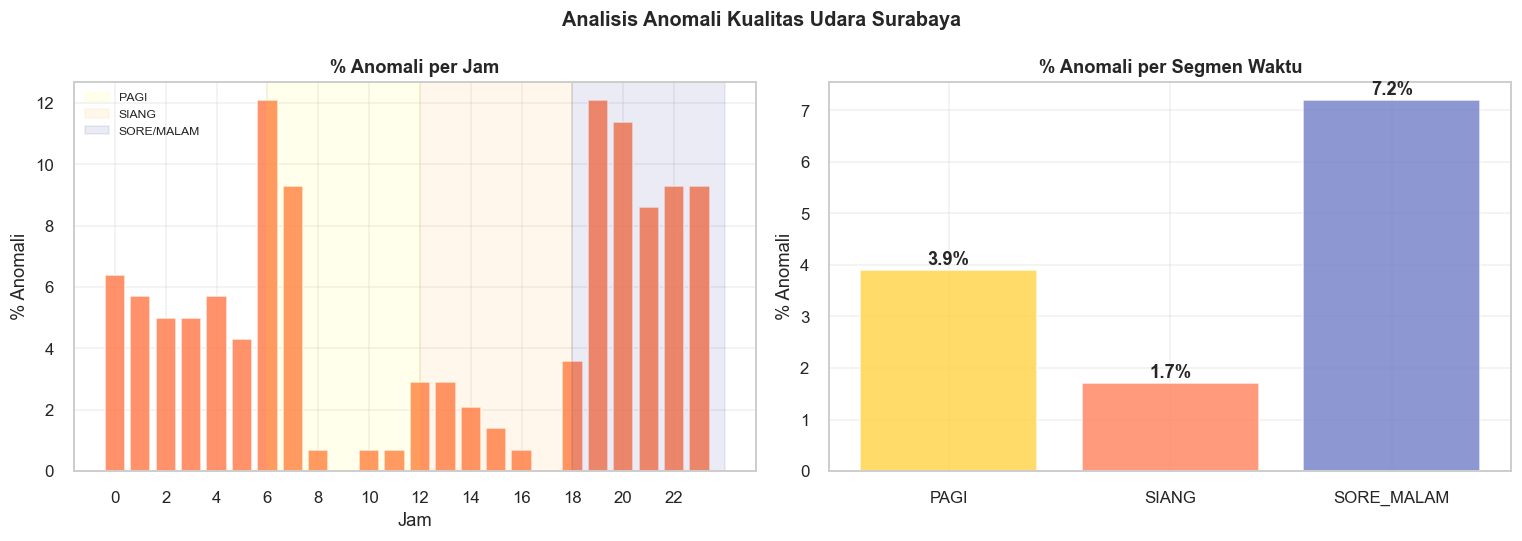

Disimpan -> reports/viz_anomali_analysis.png


In [13]:
# Visualisasi anomali
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart per jam
axes[0].bar(anomaly_per_hour.index,
            anomaly_per_hour["pct_anomali"],
            color="coral", edgecolor="white", alpha=0.85)
axes[0].axvspan(6,  12, alpha=0.08, color="yellow", label="PAGI")
axes[0].axvspan(12, 18, alpha=0.08, color="orange", label="SIANG")
axes[0].axvspan(18, 24, alpha=0.08, color="navy",   label="SORE/MALAM")
axes[0].set_title("% Anomali per Jam", fontweight="bold")
axes[0].set_xlabel("Jam")
axes[0].set_ylabel("% Anomali")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bar chart per segmen
seg_colors = ["#FFD54F", "#FF8A65", "#7986CB"]
bars = axes[1].bar(anomaly_per_seg.index,
                   anomaly_per_seg["pct_anomali"],
                   color=seg_colors, edgecolor="white", alpha=0.85)
for bar, val in zip(bars, anomaly_per_seg["pct_anomali"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f"{val:.1f}%", ha="center", fontweight="bold")
axes[1].set_title("% Anomali per Segmen Waktu", fontweight="bold")
axes[1].set_ylabel("% Anomali")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Analisis Anomali Kualitas Udara Surabaya",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz_anomali_analysis.png",
            dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_anomali_analysis.png")

## 7. Buat src/models/train_model.py

In [14]:
train_model_code = '''
"""
train_model.py – Script standalone untuk training ulang 15 model PyCaret
Kelompok Aeris | PENS 2026

Cara pakai:
    python src/models/train_model.py
    python src/models/train_model.py --polutan pm25 --segmen PAGI
"""

import os
import argparse
import pandas as pd
import numpy as np
import mlflow
import warnings
warnings.filterwarnings("ignore")

from pycaret.regression import setup, compare_models, pull, tune_model, save_model

# ── Konstanta ────────────────────────────────────────────────────
POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
SEGMEN  = ["PAGI", "SIANG", "SORE_MALAM"]

BASE_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend",
    "temperature_2m", "relative_humidity",
    "wind_speed_10m", "wind_direction_10m", "precipitation",
]
for p in POLUTAN:
    for lag in [1, 3, 24]:
        BASE_FEATURES.append(f"{p}_lag_{lag}h")
    for roll in ["rolling_mean_3h", "rolling_mean_24h",
                 "rolling_std_24h", "rolling_max_24h"]:
        BASE_FEATURES.append(f"{p}_{roll}")
    BASE_FEATURES.append(f"{p}_diff_1h")
    BASE_FEATURES.append(f"{p}_pct_change_1h")


def train_single(df, polutan, segmen):
    """Train satu kombinasi polutan x segmen."""
    combo_key  = f"{polutan}_{segmen.lower()}"
    model_path = f"models/{combo_key}_best"

    print(f"\\nTraining: {combo_key.upper()}")

    data_seg   = df[df["time_segment"] == segmen].copy()
    feat_avail = [
        c for c in BASE_FEATURES
        if c in data_seg.columns
        and c != polutan
        and not c.startswith(f"{polutan}_")
    ]
    df_model = data_seg[feat_avail + [polutan]].dropna()

    # Log-transform CO
    if polutan == "co":
        df_model = df_model.copy()
        df_model["co"] = np.log1p(df_model["co"])
        print("  [INFO] CO di-log-transform")

    print(f"  Data: {df_model.shape[0]:,} baris x {len(feat_avail)} fitur")

    # PyCaret
    exp = setup(data=df_model, target=polutan, fold=5,
                session_id=42, verbose=False, html=False,
                log_experiment=False)
    top3       = compare_models(n_select=3, sort="MAE", verbose=False)
    best_model = top3[0] if isinstance(top3, list) else top3
    best_name  = type(best_model).__name__

    compare_df = pull()
    best_row   = compare_df.iloc[0]
    mae_val    = round(float(best_row.get("MAE", 0)), 4)
    rmse_val   = round(float(best_row.get("RMSE", 0)), 4)
    r2_val     = round(float(best_row.get("R2", 0)), 4)

    tuned      = tune_model(best_model, optimize="MAE", verbose=False)
    tuned_df   = pull()
    tuned_row  = tuned_df.iloc[0] if len(tuned_df) > 0 else best_row
    mae_tuned  = round(float(tuned_row.get("MAE", mae_val)), 4)

    # Pilih model terbaik
    final_model = best_model if mae_tuned > mae_val else tuned
    mae_final   = mae_val if mae_tuned > mae_val else mae_tuned

    save_model(final_model, model_path)
    print(f"  Model: {best_name} | MAE={mae_final:.4f} | R2={r2_val:.4f}")
    print(f"  Disimpan: {model_path}.pkl")

    # Log ke MLflow
    with mlflow.start_run(run_name=f"retrain_{combo_key}"):
        mlflow.log_params({"polutan": polutan, "segmen": segmen,
                           "model_name": best_name})
        mlflow.log_metrics({"mae_final": mae_final, "r2": r2_val})
        mlflow.log_artifact(f"{model_path}.pkl")

    return {"polutan": polutan, "segmen": segmen,
            "model": best_name, "mae": mae_final, "r2": r2_val}


def train_all(data_path="data/processed/surabaya_processed.csv"):
    """Train ulang semua 15 kombinasi model."""
    print("=" * 55)
    print("RETRAINING 15 MODEL")
    print("=" * 55)

    df = pd.read_csv(data_path, parse_dates=["time"])
    mlflow.set_tracking_uri("mlruns")
    mlflow.set_experiment("aeris-air-quality-retrain")

    rekap = []
    for segmen in SEGMEN:
        for polutan in POLUTAN:
            result = train_single(df, polutan, segmen)
            rekap.append(result)

    print("\\n" + "=" * 55)
    print("RETRAINING SELESAI!")
    print("=" * 55)

    df_rekap = pd.DataFrame(rekap)
    df_rekap.to_csv("reports/rekap_retrain.csv", index=False)
    print(f"Rekap disimpan -> reports/rekap_retrain.csv")
    return df_rekap


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Train ulang model PyCaret")
    parser.add_argument("--polutan", type=str, default=None,
                        choices=POLUTAN, help="Polutan tertentu")
    parser.add_argument("--segmen", type=str, default=None,
                        choices=SEGMEN, help="Segmen tertentu")
    args = parser.parse_args()

    df = pd.read_csv("data/processed/surabaya_processed.csv",
                     parse_dates=["time"])
    mlflow.set_tracking_uri("mlruns")
    mlflow.set_experiment("aeris-air-quality-retrain")

    if args.polutan and args.segmen:
        train_single(df, args.polutan, args.segmen)
    else:
        train_all()
'''

with open("src/models/train_model.py", "w", encoding="utf-8") as f:
    f.write(train_model_code.strip())

print("train_model.py dibuat -> src/models/train_model.py")

train_model.py dibuat -> src/models/train_model.py


## 8. Buat src/models/predict_model.py

In [15]:
predict_model_code = '''
"""
predict_model.py – Script inferensi untuk prediksi polutan
Kelompok Aeris | PENS 2026

Cara pakai:
    from src.models.predict_model import PredictorAeris
    predictor = PredictorAeris()
    hasil = predictor.predict_current(df_input)
"""

import os
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from pycaret.regression import load_model, predict_model

POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]

BASE_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend",
    "temperature_2m", "relative_humidity",
    "wind_speed_10m", "wind_direction_10m", "precipitation",
]
for p in POLUTAN:
    for lag in [1, 3, 24]:
        BASE_FEATURES.append(f"{p}_lag_{lag}h")
    for roll in ["rolling_mean_3h", "rolling_mean_24h",
                 "rolling_std_24h", "rolling_max_24h"]:
        BASE_FEATURES.append(f"{p}_{roll}")
    BASE_FEATURES.append(f"{p}_diff_1h")
    BASE_FEATURES.append(f"{p}_pct_change_1h")


def get_time_segment(hour=None):
    """Deteksi segmen waktu berdasarkan jam."""
    if hour is None:
        hour = datetime.now().hour
    if 6 <= hour <= 11:    return "PAGI"
    elif 12 <= hour <= 17: return "SIANG"
    else:                  return "SORE_MALAM"


class PredictorAeris:
    """Class untuk inferensi model polutan udara."""

    def __init__(self, models_dir="models"):
        self.models_dir = models_dir
        self.models     = {}
        self._load_all_models()

    def _load_all_models(self):
        """Load semua 15 model ke memori."""
        SEGMEN = ["PAGI", "SIANG", "SORE_MALAM"]
        for seg in SEGMEN:
            for pol in POLUTAN:
                key  = f"{pol}_{seg.lower()}"
                path = os.path.join(self.models_dir, f"{key}_best")
                try:
                    self.models[key] = load_model(path, verbose=False)
                except Exception as e:
                    print(f"[WARN] Gagal load {path}: {e}")
        print(f"[INFO] {len(self.models)} model berhasil di-load")

    def predict_current(self, df_input, hour=None):
        """
        Prediksi semua polutan berdasarkan data input.

        Args:
            df_input: DataFrame dengan fitur input (1 baris)
            hour: jam override (opsional, default jam sekarang)

        Returns:
            dict: prediksi per polutan + segmen waktu
        """
        segmen = get_time_segment(hour)
        result = {
            "timestamp" : datetime.now().isoformat(),
            "segmen"    : segmen,
            "prediksi"  : {}
        }

        for pol in POLUTAN:
            key        = f"{pol}_{segmen.lower()}"
            feat_avail = [
                c for c in BASE_FEATURES
                if c in df_input.columns
                and c != pol
                and not c.startswith(f"{pol}_")
            ]

            if key not in self.models:
                result["prediksi"][pol] = None
                continue

            try:
                X = df_input[feat_avail].copy()

                # Log-transform CO sebelum prediksi
                if pol == "co" and "co" in X.columns:
                    X["co"] = np.log1p(X["co"])

                pred = predict_model(self.models[key],
                                     data=X, verbose=False)
                pred_val = float(pred["prediction_label"].values[0])

                # Inverse log-transform CO
                if pol == "co":
                    pred_val = float(np.expm1(pred_val))

                result["prediksi"][pol] = round(pred_val, 4)
            except Exception as e:
                print(f"[WARN] Gagal prediksi {pol}: {e}")
                result["prediksi"][pol] = None

        return result

    def predict_batch(self, df_batch):
        """
        Prediksi batch untuk banyak baris sekaligus.

        Args:
            df_batch: DataFrame dengan kolom hour + fitur input

        Returns:
            DataFrame: hasil prediksi semua baris
        """
        results = []
        for _, row in df_batch.iterrows():
            hour   = int(row["hour"]) if "hour" in row else None
            result = self.predict_current(
                pd.DataFrame([row]), hour=hour
            )
            row_result = {"timestamp": row.get("time", None),
                          "segmen": result["segmen"]}
            row_result.update({f"{p}_pred": result["prediksi"][p]
                               for p in POLUTAN})
            results.append(row_result)

        return pd.DataFrame(results)
'''

with open("src/models/predict_model.py", "w", encoding="utf-8") as f:
    f.write(predict_model_code.strip())

print("predict_model.py dibuat -> src/models/predict_model.py")

predict_model.py dibuat -> src/models/predict_model.py


## 9. Dokumentasi Pipeline

In [16]:
from datetime import datetime

pipeline_doc = f"""# Pipeline Documentation – Aeris Air Quality System

**Tanggal:** {datetime.today().strftime('%d %B %Y')}  
**Proyek:** Sistem Deteksi Anomali Kualitas Udara – Kelompok Aeris PENS 2026  
**PIC:** Linda Anggara Wati

---

## Alur Pipeline Lengkap

```
Open-Meteo API
     |
     v
[FETCH] src/data/fetch_data.py
  - Polutan: PM2.5, PM10, CO, NO2, O3
  - Meteorologi: suhu, kelembaban, angin, hujan
  - Frekuensi: tiap 1 jam (APScheduler)
     |
     v
[PREPROCESS] notebooks/02_preprocessing.ipynb
  - Handle missing values (interpolasi linear)
  - Feature engineering: lag, rolling, diff
  - Segmentasi waktu: PAGI / SIANG / SORE_MALAM
  - Hitung ISPU (Permen LHK 14/2020)
  - StandardScaler normalisasi
     |
     v
[PREDICT] src/models/predict_model.py
  - Deteksi segmen waktu saat ini
  - Load model .pkl sesuai segmen
  - Prediksi 5 polutan sekaligus
  - Inverse transform CO (expm1)
     |
     v
[ANOMALY] src/models/anomaly.py
  - Isolation Forest (contamination=0.05)
  - Output: is_anomaly + anomaly_score
     |
     v
[SAVE] PostgreSQL (Supabase)
  - Tabel: air_quality_raw
  - Tabel: predictions
  - Tabel: anomaly_results
     |
     v
[API] FastAPI src/api/main.py
  - GET /status/surabaya
  - GET /ispu/surabaya
  - GET /predict/surabaya
  - GET /anomaly/surabaya
  - GET /history/surabaya
     |
     v
[FRONTEND] Dashboard HTML/CSS/JS
  - Panel ISPU real-time
  - Prediksi 3 jam ke depan
  - Grafik historis
  - Notifikasi anomali
```

---

## Segmentasi Waktu

| Segmen | Jam | Model yang Diload |
|---|---|---|
| PAGI | 06:00–11:59 | `models/{{polutan}}_pagi_best.pkl` |
| SIANG | 12:00–17:59 | `models/{{polutan}}_siang_best.pkl` |
| SORE_MALAM | 18:00–05:59 | `models/{{polutan}}_sore_malam_best.pkl` |

---

## 15 Model PyCaret

| Polutan | PAGI | SIANG | SORE_MALAM |
|---|---|---|---|
| PM25 | BayesianRidge | BayesianRidge | BayesianRidge |
| PM10 | BayesianRidge | BayesianRidge | BayesianRidge |
| CO | LGBMRegressor | LGBMRegressor | ExtraTreesRegressor |
| NO2 | LGBMRegressor | ExtraTreesRegressor | ExtraTreesRegressor |
| O3 | LGBMRegressor | LGBMRegressor | ExtraTreesRegressor |

---

## Cara Menjalankan Pipeline

### Training ulang semua model:
```bash
python src/models/train_model.py
```

### Training ulang 1 kombinasi:
```bash
python src/models/train_model.py --polutan pm25 --segmen PAGI
```

### Prediksi dari Python:
```python
from src.models.predict_model import PredictorAeris
predictor = PredictorAeris()
hasil = predictor.predict_current(df_input)
print(hasil)
```

### Jalankan API:
```bash
uvicorn src.api.main:app --reload
```

### Jalankan dengan Docker:
```bash
docker-compose up --build
```

---

## Catatan Teknis

- CO menggunakan **log1p transform** sebelum training dan **expm1** saat inferensi
- Semua model dipilih berdasarkan MAE terkecil (before tune vs after tune)
- Isolation Forest contamination rate = 0.05 (5% data dianggap anomali)
- Data di-fetch tiap 1 jam via APScheduler
- Retrain otomatis tiap Minggu jam 01:00 WIB
"""

with open("reports/pipeline_doc.md", "w", encoding="utf-8") as f:
    f.write(pipeline_doc)

print("Pipeline doc -> reports/pipeline_doc.md")

Pipeline doc -> reports/pipeline_doc.md


## 10. Ringkasan Minggu 4

In [17]:
print("=" * 62)
print("RINGKASAN MINGGU 4 – LINDA ANGGARA WATI")
print("=" * 62)
print("""
TOLAK UKUR KEBERHASILAN MINGGU 4 (Linda):

[OK] Pipeline end-to-end berjalan
     Fetch -> Preprocess -> Predict -> Save

[OK] Segmentasi waktu otomatis bekerja
     Jam 08:00 -> PAGI -> load models/[polutan]_pagi_best.pkl
     Jam 13:00 -> SIANG -> load models/[polutan]_siang_best.pkl
     Jam 20:00 -> SORE_MALAM -> load models/[polutan]_sore_malam_best.pkl

[OK] Monitor prediksi vs aktual -> viz_pipeline_pred_vs_actual.png

[OK] Analisis anomali selesai -> viz_anomali_analysis.png

[OK] src/models/train_model.py dibuat (script standalone retrain)

[OK] src/models/predict_model.py dibuat (class PredictorAeris)

[OK] reports/pipeline_doc.md selesai

FILE OUTPUT:
  src/models/train_model.py
  src/models/predict_model.py
  reports/pipeline_doc.md
  reports/viz_pipeline_pred_vs_actual.png
  reports/viz_anomali_analysis.png
  data/processed/pipeline_test_predictions.csv

HANDOVER KE YUHANIDZ:
  - src/models/predict_model.py siap di-import di FastAPI
  - Cara pakai: from src.models.predict_model import PredictorAeris
  - src/models/train_model.py untuk retraining otomatis APScheduler
""")
print("Minggu 4 selesai! Siap lanjut Minggu 5: Finalisasi & Presentasi.")

RINGKASAN MINGGU 4 – LINDA ANGGARA WATI

TOLAK UKUR KEBERHASILAN MINGGU 4 (Linda):

[OK] Pipeline end-to-end berjalan
     Fetch -> Preprocess -> Predict -> Save

[OK] Segmentasi waktu otomatis bekerja
     Jam 08:00 -> PAGI -> load models/[polutan]_pagi_best.pkl
     Jam 13:00 -> SIANG -> load models/[polutan]_siang_best.pkl
     Jam 20:00 -> SORE_MALAM -> load models/[polutan]_sore_malam_best.pkl

[OK] Monitor prediksi vs aktual -> viz_pipeline_pred_vs_actual.png

[OK] Analisis anomali selesai -> viz_anomali_analysis.png

[OK] src/models/train_model.py dibuat (script standalone retrain)

[OK] src/models/predict_model.py dibuat (class PredictorAeris)

[OK] reports/pipeline_doc.md selesai

FILE OUTPUT:
  src/models/train_model.py
  src/models/predict_model.py
  reports/pipeline_doc.md
  reports/viz_pipeline_pred_vs_actual.png
  reports/viz_anomali_analysis.png
  data/processed/pipeline_test_predictions.csv

HANDOVER KE YUHANIDZ:
  - src/models/predict_model.py siap di-import di FastAPI